# Reinforcement Learning for Robot Maze Navigation

Training a TurtleBot3 to navigate a Gazebo maze to a goal pillar using two
reinforcement-learning approaches: Sarsa(λ) with tile-coded linear function
approximation, and an Actor-Critic policy gradient with a neural network.

---

The `REVIEW_MODE` flag below skips the long Gazebo training runs and loads the
saved run data instead, so the results render without ROS or a robot.

In [16]:
REVIEW_MODE = True

<br>

## 1. Summary and Introduction

A fundamental task for a robotic agent in many cases is learning to navigate it's environment. Often, in real-world scenarios, we encounter continuous variables such as distances and angles that can be divided into infinitely small values. Consequently, employing tabular methods to compute every possible state or state-action pair becomes impractical, if not impossible. In these circumstances, function approximation techniques are crucial tools for training an agent. 

In this project, I will employ two function approximation methods to train a robotic agent to navigate a simple maze-like environment (Fig. 1) to come within 2ft of one of the two white pillars without hitting any orange walls.

<br>

<div>
<img src="gazebo_env.png" width="500"/>
</div>

_Fig. 1: Gazebo turtlebot assessment 2 environment (each square is 1mx1m)_

<br>

Importing python libraries:

In [2]:
from rl import linear

#------------ ros -----------#
import rclpy as ros
from rclpy.node import Node
from std_srvs.srv import Empty
from gazebo_msgs.srv import SpawnModel
from geometry_msgs.msg import Twist
from sensor_msgs.msg import LaserScan
from nav_msgs.msg  import Odometry

#-------- mathematics -------#
import numpy as np
from numpy import Inf
from math import atan2, sqrt

#------- visualisation ------#
import matplotlib.pyplot as plt
from IPython.display import clear_output

#------ object storage ------#
import json
import pickle

#----------- misc. ----------#
import threading
import itertools
from time import sleep

<br>

## 2. ROS Environment Class

During testing, I found that running the subscriber and publisher in the same thread led to inconsistent robot movements. Therefore, before writing the main environment class, I will build a subscriber node to be run in a separate thread. This node will capture the agent's pose and the lidar scans in global variables so the main environment class can access them.

In [3]:
# Credit to salmagro on GitHub for this function. 
# https://gist.github.com/salmagro/2e698ad4fbf9dae40244769c5ab74434
def euler_from_quaternion(quaternion):
    x = quaternion.x
    y = quaternion.y
    z = quaternion.z
    w = quaternion.w

    sinr_cosp = 2 * (w * x + y * z)
    cosr_cosp = 1 - 2 * (x * x + y * y)
    roll = np.arctan2(sinr_cosp, cosr_cosp)

    sinp = 2 * (w * y - z * x)
    pitch = np.arcsin(sinp)

    siny_cosp = 2 * (w * z + x * y)
    cosy_cosp = 1 - 2 * (y * y + z * z)
    yaw = np.arctan2(siny_cosp, cosy_cosp)

    return roll, pitch, yaw

class GetState(Node):
   
    def __init__(self, name='State_subscriber'):
        super().__init__(name)

        self.range_max = 3.5

        self.scanner = self.create_subscription(LaserScan, '/scan', self.scan, 0)
        self.odometry = self.create_subscription(Odometry, '/odom', self.odom_callback, 0)

    def scan(self, scans):
        scans = np.array(scans.ranges)
        scans[scans==Inf] = self.range_max
        self.scans = scans
        
        global last_scans
        last_scans = scans
    
    def odom_callback(self, msg):
        x = msg.pose.pose.position.x
        y = msg.pose.pose.position.y

        global last_pose
        last_pose = (x, y)
        
        orientation = msg.pose.pose.orientation
        
        global last_orientation
        last_orientation = euler_from_quaternion(orientation)

In the environment class below, I define methods to publish 3 actions to the agent: move forward, rotate clockwise and rotate anti-clockwise. I have also added a stop method and a reset method to return the robot to the centre when it crashes or finishes an episode by reaching the goal or the step limit.

The state and reward methods are implemented in section 3, next to the state representation they depend on.

In [4]:
class GazeboEnv(Node):

    def __init__(
            self, 
            name='Gazebo_Env',  
            frequency=1/20, 
            speed=0.5, 
            θspeed=0.5,
            n=20
            ):
        super().__init__(name)
        
        #---------- agent control -----------#
        self.nA = 3
        self.n = n
        self.speed = speed
        self.θspeed = θspeed
        self.a = -1
        self.robot = Twist()

        self.controller = self.create_publisher(Twist, '/cmd_vel', 0)
        self.timer = self.create_timer(frequency, self.control)
        self.reset_world = self.create_client(Empty, "/reset_world")
        
        #----------- compatibility ------------#
        self.Vstar = None

  #------- Methods for taking actions -------#
    def control(self): 
        self.controller.publish(self.robot) 

    def spin_n(self, n):
        for _ in range(n): ros.spin_once(self)
        
    def step(self, a=1, speed=None, θspeed=None):
        if speed is None: speed = self.speed
        if θspeed is None: θspeed = self.θspeed
        
        if  a==-1: self.robot.linear.x  = -speed  # backwards
        elif a==1: self.robot.linear.x  =  speed  # forwards
        elif a==0: self.robot.angular.z =  θspeed # turn left
        elif a==2: self.robot.angular.z = -θspeed # turn right
 
        self.spin_n(self.n) if a==1 else self.spin_n(self.n//2)
        self.stop()

        sn, r, done = self.s_(), self.reward(a), self.isatgoal()
        
        self.previous_distance_from_goal = self.distance_from_goal()
        
        if self.iscrashed() or done:
            self.reset()
            sleep(1)
            
        return sn, r, done, {}
    
    def stop(self):
        self.robot.linear.x = .0
        self.robot.angular.z = .0
        self.spin_n(self.n//8)

    def reset(self):
        self.reset_world.call_async(Empty.Request())
        return self.s_()
      
  #------------- Compatibility --------------#
    def S_(self):
        return np.eye(self.nF)
    
    def render(self, **kw): 
        return
    
  #-------- Implemented in section 3 -------#
    def s_(self):
        raise NotImplementedError
    
    def distance_from_goal(self):
        raise NotImplementedError

    def isatgoal(self):
        raise NotImplementedError
        
    def iscrashed(self):
        raise NotImplementedError

    def reward(self):
        raise NotImplementedError

<br>

## 3. Robot model 1: Action Value-function with Linear Function Approximation

#### _State Representation:_

In many real-world settings using odometery is impractical due to uncertainty and reading inaccuracy. Algorithms such as SLAM can account for this but are beyond the scope of this project. Therefore, we will only use the laser scanner readings to represent the state-space. 

Currently, the 60 features in the laser scan vector will be active too often for learning to converge efficiently. Therefore, to improve performance I will introduce sparsity by implementing tile-encoding. Each laser reading will be represented by a one-hot encoded vector of dimension $\#tiles$.

I will use multiple offset tilings to further increase the sparsity of the state representation, however, it will be important to test this variable. Too many tilings will slow down learning significantly but too few may prevent convergence.

The state vector will be of dimension: $ (\#tilings\times\#tiles\times\#lasers) $ and the number of active features will be: $ (\#tilings\times\#lasers) $.

#### _Reward Function:_

The reward function is key to shaping the agent's behaviour so we must craft it carefully. The objective is for the agent to find the shortest path to the goal. Therefore, crashing and reaching the goal will receive high negative and high positive rewards respectively. 

In addition, I will give the sum of the agent's euclidean and angular distances from the goal as a negative intermediate reward. This will encourage the agent to be pointed at the goal and move towards the goal. 

Note, I am giving a positive reward only when the agent reaches the goal. Since the agent will aim to always maximise reward, positive intermediate rewards could encourage longer journeys, whereas negative intermediate rewards will always encourage the agent to find the shortest path to the goal. 

I have chosen to only give intermediate rewards in relation to the NW goal. Encouraging the agent towards a preferred goal will significantly speed up training.

Finally, to slightly encourage forward movement, we will give non-forward movement an additional reward of -1. 

In [5]:
class GazeboEnvV(GazeboEnv):

    def __init__(
            self, 
            num_lasers=60, 
            num_tiles=30,
            num_tilings=20,
            laser_range=[0, 3.5],
            single_goal=False,
            **kw):
        
        super().__init__(**kw)

        #----------------- goals -----------------#
        self.goal1 = [2, 2]
        self.goal2 = [-2, -2]
        self.goal_tolerance = 0.66 # 2 feet: the target tolerance.
        self.single_goal = single_goal
        self.last_goal_dist = sqrt(8)

        #--------- state representation ----------#
        self.num_tilings = num_tilings
        self.num_tiles = num_tiles
        self.num_lasers = num_lasers
        self.laser_range = [0, 3.5]
        self.tile_width = (laser_range[1] - laser_range[0]) / num_tiles
        self.tile_offsets = np.arange(num_tilings) * self.tile_width / num_tilings
        self.nS = self.nF = self.num_lasers * self.num_tiles * self.num_tilings

  #------ Method for getting the state -----#
    def s_(self):
        laser_scans = last_scans
        feature_vector = np.zeros((self.num_lasers, self.num_tiles * self.num_tilings))

        for i in range(self.num_lasers):
            laser_value = laser_scans[i]
            
            for j in range(self.num_tilings):
                tile_index = int((laser_value - self.laser_range[0] + self.tile_offsets[j]) / self.tile_width)
                tile_index = np.clip(tile_index, 0, self.num_tiles - 1)
                feature_index = j * self.num_tiles + tile_index
                feature_vector[i, feature_index] = 1

        return feature_vector.flatten()
    
  #---- Methods for evaluating the reward ---#
    def isatgoal(self):
        if self.distance_from_goal() < self.goal_tolerance:
            return True
        else:
            return False
        
    def iscrashed(self):
        scans_seeing_an_obstacle = [s for s in last_scans if s < .2]
        return len(scans_seeing_an_obstacle) >= 1
    
    def distance_from_goal(self):
        x, y = last_pose

        goal1_dist = sqrt((x - self.goal1[0])**2 + (y - self.goal1[1])**2)
        goal2_dist = sqrt((x - self.goal2[0])**2 + (y - self.goal2[1])**2)

        if self.single_goal:
            return goal1_dist
        else:
            return min(goal1_dist, goal2_dist)
        
    def θgoal(self, goal):
        xgoal, ygoal = goal 
        x, y  = last_pose
        θgoal = atan2(abs(xgoal-x), abs(ygoal-y)) 
        return round(θgoal, 2) 
    
    def reward(self, a):
        if self.isatgoal():
            return 10
        elif self.iscrashed():
            return -10
        else:
            goal_dist = self.distance_from_goal()
            goal_diff = self.last_goal_dist-goal_dist
            θ_goal = self.θgoal(self.goal1)
            θ_dist = abs(last_orientation[2] - θ_goal)
            if a == 1:
                return goal_diff-(goal_dist + θ_dist)
            else:
                return -1-(goal_dist + θ_dist)

<br>

Below are utility functions: serialising and deserialising trained models and initialising the environment.

In [6]:
def start_environment(env_class, env_parameters):
    try:
        ros.shutdown()   
    except:
        pass
    
    ros.init()
    get_state = GetState()
    env = env_class(**env_parameters)

    executor = ros.executors.MultiThreadedExecutor()
    executor.add_node(env)
    executor.add_node(get_state)
    executor_thread = threading.Thread(target=executor.spin, daemon=True)
    executor_thread.start()
    sleep(3)
    env.reset()
    return env

def save_model(model, filepath):
    model.env = None
    with open(filepath, "wb") as file:
        pickle.dump(model, file)
    return 

def load_model(filepath):
    with open(filepath, "rb") as file:
        model = pickle.load(file)
    return model

<br>

#### _RL Algorithm_

We will be using Sarsa with eligibility traces. Sarsa suits to our use case as it's an action-value approximatng online algorithm so will make use of the rewards from the environment during an episode. Furthermore, eligibility traces can speed up the convergence of the learning process by allowing the agent to update the value estimates of multiple state-action pairs in a single step.

In [4]:
# Shown here for reference; the same class is provided as rl.linear.Sarsaλ.
class Sarsaλ(linear.MDP):
    def __init__(self, λ=.5, **kw):
        super().__init__(**kw)
        self.λ = λ
        self.step = self.step_an # for Sarsa we want to decide the next action in time step t
    
    def step0(self):
        self.Z = self.W*0
    # ----------------------------------------🌖 online learning ----------------------------------------
    def online(self, s, rn,sn, done, a,an):
        self.Z[a] = self.λ*self.γ*self.Z[a] + self.ΔQ(s)
        self.W[a] += self.α*(rn + (1-done)*self.γ*self.Q(sn,an)- self.Q(s,a))*self.Z[a]


<br>

#### _Hyper Parameter Tuning_

The two key parameters I will tune for Sarsaλ are **The Learning Rate (α)** and **The Eligibility Trace Parameter (λ)**. Typically, these parameters have a similar impact on the learning process. Explicitly, higher values of both **λ** and **α** often lead to faster learning but may introduce more variance. However, the effect is problem dependant and therefore it is crucial that we conduct hyper-parameter tuning on these values.

It is important to note that α will always be divided by the number of active features in our state which equals num_tilings*num_lasers.

In addition, as mentioned in the state-representation section I will testing the num_tilings environment parameter.

<br>

The following cells contain the code used to conduct hyper-parameter tuning, save the results and display the final graphs.

In [5]:
REVIEW_MODE = True
episodes = 20 # Episodes per training cycle.
env_or_rl = "rl" # "env" to test environment params and "rl" for Sarsa 

hyperparams = {
    "α": (0.3, 0.5, 0.8),
    "λ": (0.3, 0.5, 0.8)
#     "num_tilings": (10, 15, 20),
}

#------- Base params to update ------#
base_rl_parameters = {
    "α": 0.5, 
    "λ": 0.5,
    "ε": 0.1,
    "γ": 0.9,
    "episodes": episodes,
    "max_t": 200,
}

base_env_parameters = {
    "num_lasers": 60, 
    "num_tiles": 30,
    "num_tilings": 20,
    "single_goal": True
}
#-----------------------------------#


#------- Preparing Grid Search -------#
param_names = list(hyperparams.keys())
param_values = list(hyperparams.values())
combinations = list(itertools.product(*param_values))
for combo in combinations:
    env_parameters = base_env_parameters.copy()
    rl_parameters = base_rl_parameters.copy()
    
    if env_or_rl == "env":
        for name, value in zip(param_names, combo):
            env_parameters[name] = value
        print("Env Params:", env_parameters)
    else:
        for name, value in zip(param_names, combo):
            rl_parameters[name] = value
        print("RL Params:", rl_parameters)

    output_label = ", ".join([f"{p}={v}" for p, v in zip(param_names, combo)])
    output_model_path = f"saved_models/sarsa_{episodes}_({output_label}).pkl"
    
    print("Output Path:", output_model_path)
    print()

#------ Training for each Combo ------#
    if not REVIEW_MODE:
        rl_parameters["α"] = rl_parameters["α"]/(60*env_parameters["num_tilings"])
        gz_env = start_environment(GazeboEnvV, env_parameters)
        sarsa = linear.Sarsaλ(env=gz_env, **rl_parameters)
        sarsa = sarsa.interact()
        save_model(sarsa, output_model_path)
        ros.shutdown()

print("Grid Search Finished!")

RL Params: {'α': 0.3, 'λ': 0.3, 'ε': 0.1, 'γ': 0.9, 'episodes': 20, 'max_t': 200}
Output Path: saved_models/sarsa_20_(α=0.3, λ=0.3).pkl

RL Params: {'α': 0.3, 'λ': 0.5, 'ε': 0.1, 'γ': 0.9, 'episodes': 20, 'max_t': 200}
Output Path: saved_models/sarsa_20_(α=0.3, λ=0.5).pkl

RL Params: {'α': 0.3, 'λ': 0.8, 'ε': 0.1, 'γ': 0.9, 'episodes': 20, 'max_t': 200}
Output Path: saved_models/sarsa_20_(α=0.3, λ=0.8).pkl

RL Params: {'α': 0.5, 'λ': 0.3, 'ε': 0.1, 'γ': 0.9, 'episodes': 20, 'max_t': 200}
Output Path: saved_models/sarsa_20_(α=0.5, λ=0.3).pkl

RL Params: {'α': 0.5, 'λ': 0.5, 'ε': 0.1, 'γ': 0.9, 'episodes': 20, 'max_t': 200}
Output Path: saved_models/sarsa_20_(α=0.5, λ=0.5).pkl

RL Params: {'α': 0.5, 'λ': 0.8, 'ε': 0.1, 'γ': 0.9, 'episodes': 20, 'max_t': 200}
Output Path: saved_models/sarsa_20_(α=0.5, λ=0.8).pkl

RL Params: {'α': 0.8, 'λ': 0.3, 'ε': 0.1, 'γ': 0.9, 'episodes': 20, 'max_t': 200}
Output Path: saved_models/sarsa_20_(α=0.8, λ=0.3).pkl

RL Params: {'α': 0.8, 'λ': 0.5, 'ε': 0.1,

Aggregating the saved run data so the results can be displayed below.

In [9]:
if not REVIEW_MODE:
    outpath = "" # Left blank incase of accidental run.
    models = [
        "sarsa_50_(α=0.3, λ=0.3)", 
        "sarsa_50_(α=0.3, λ=0.5)", 
        "sarsa_50_(α=0.3, λ=0.8)",
        "sarsa_50_(α=0.5, λ=0.3)",
        "sarsa_50_(α=0.5, λ=0.5)",
        "sarsa_50_(α=0.5, λ=0.8)",
        "sarsa_50_(α=0.8, λ=0.3)",
        "sarsa_50_(α=0.8, λ=0.5)", 
        "sarsa_50_(α=0.8, λ=0.8)"
    ]
    # models = [
    #     "sarsa_20_(num_tilings=10)", 
    #     "sarsa_20_(num_tilings=15)",
    #     "sarsa_20_(num_tilings=20)"
    # ]
    # outpath = ""
    # models = [
    #     "sarsa_250_(α=0.3, λ=0.3)", 
    #     "sarsa_250_(α=0.8, λ=0.5)", 
    # ]

    data = {}
    for model in models:
        sarsa_load = load_model(f"saved_models/{model}.pkl")
        data[model] = {
            "Ts": sarsa_load.Ts.tolist(),
            "Rs": sarsa_load.Rs.tolist(),
        }
        
    with open(outpath, "w") as f:
        f.write(json.dumps(data))

Function for displaying aggregated results.

In [5]:
def display_stored_results(model_data_list, highlight_model=None, only_show=None):
    T_lists = []
    R_lists = []
    labels = []

    for key, value in model_data_list.items():
        if only_show and key not in only_show:
            continue
        T_lists.append(value['Ts'])
        R_lists.append(value['Rs'])
        labels.append(key)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    for steps, name in zip(T_lists, labels):
        if highlight_model:
            if highlight_model in name:
                ax1.plot(steps, '--', label="steps " + name.replace("_", " "), alpha=1.0)
            else:
                ax1.plot(steps, '--', label="steps " + name.replace("_", " "), alpha=0.3)
        else:
            ax1.plot(steps, '--', label="steps " + name.replace("_", " "))
    ax1.set_title('Steps')
    ax1.set_xlabel('Episode')
    ax1.set_ylabel('Steps')
    ax1.legend()

    for rewards, name in zip(R_lists, labels):
        if highlight_model:
            if highlight_model in name:
                ax2.plot(rewards, '--', label='Σrewards ' + name.replace("_", " "), alpha=1.0)
            else:
                ax2.plot(rewards, '--', label='Σrewards ' + name.replace("_", " "), alpha=0.2)
        else:
            ax2.plot(rewards, '--', label='Σrewards ' + name.replace("_", " "))
    ax2.set_title('ΣRewards')
    ax2.set_xlabel('Episode')
    ax2.set_ylabel('ΣRewards')
    ax2.legend()
    
    clear_output(wait=True)
    plt.tight_layout()
    plt.show()

<br>

#### _Hyper-parameter Selection_

In this section we will make our final hyper-parameter selections. I will weight my choices towards future stability rather than faster convergence.

For example with the num_tilings parameter all options are showing promising signs of convergence so to ensure that in future episodes we don't encounter problems with state-collision I will favour the higher value of 20.

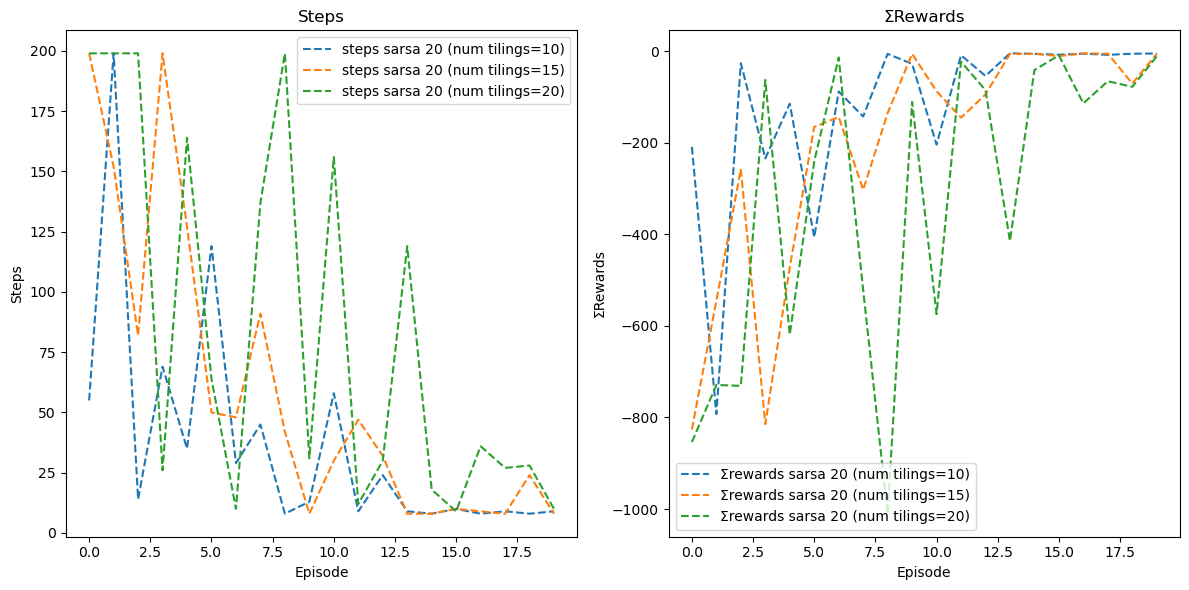

In [8]:
with open("saved_run_data/hyperparam_tuning_tilings.json", "r") as f:
    hpt_results = json.load(f)
display_stored_results(hpt_results)


<br>

Next, we can see which combination of α and λ performed best. We are looking for a good speed of convergence but crucially a stable solution once converged.

In the next cell I display all the run's step counts and rewards together. The graph is instructive but a little hard to read so I have added the ability to highlight one model at a time. I have also formatted some stats for review.

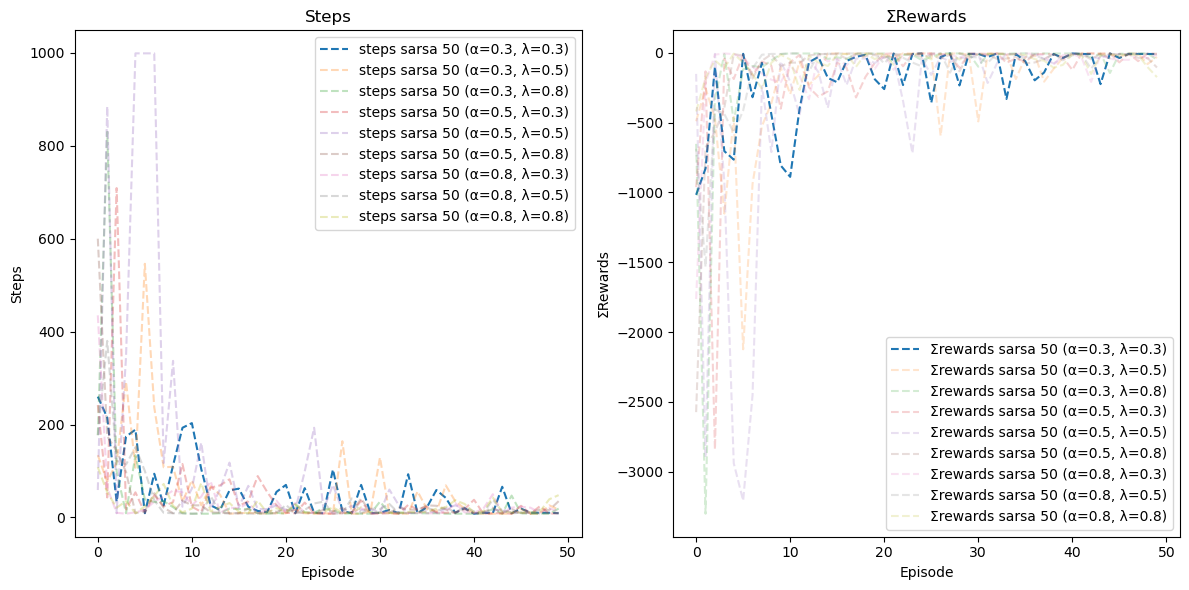

 Label                  | Total ΣRewards | Last 40 ΣRewards | Last 10 ΣRewards 
-------------------------------------------------------------------------------
sarsa_50_(α=0.3, λ=0.3) |       -9453.79 |         -4386.85 |          -328.70
sarsa_50_(α=0.3, λ=0.5) |       -9650.16 |         -2768.25 |          -188.03
sarsa_50_(α=0.3, λ=0.8) |       -5985.72 |          -816.59 |          -273.84
sarsa_50_(α=0.5, λ=0.3) |       -7403.19 |         -2503.26 |          -296.87
sarsa_50_(α=0.5, λ=0.5) |      -17417.48 |         -3824.02 |          -120.33
sarsa_50_(α=0.5, λ=0.8) |       -5901.41 |         -1308.59 |          -322.53
sarsa_50_(α=0.8, λ=0.3) |       -4591.88 |         -1888.80 |          -479.49
sarsa_50_(α=0.8, λ=0.5) |       -5410.93 |         -1213.10 |          -232.85
sarsa_50_(α=0.8, λ=0.8) |       -3199.93 |         -1855.33 |          -539.74


In [9]:
with open("saved_run_data/hyperparam_tuning.json", "r") as f:
    hp_results = json.load(f)
    
for model in list(hp_results.keys())[::-1]:
    display_stored_results(hp_results, model)
    sleep(1)

print(" Label                  | Total ΣRewards | Last 40 ΣRewards | Last 10 ΣRewards ")
print("-------------------------------------------------------------------------------")
for model, data in hp_results.items():
    print(f"{model:10} | {sum(data['Rs']):14.2f} | {sum(data['Rs'][10:]):16.2f} | {sum(data['Rs'][40:]):16.2f}")

Hyper-parameter combo (α=0.8, λ=0.5) had the best overall performance. With 2nd highest total ΣRewards and last 40 episode ΣRewards, with 3rd highest final 10 episode ΣRewards and peaks that trend downwards.

Hyper-params (α=0.3, λ=0.3) had poor numerical performance but the peaks consistently trend downwards quickly. 

I took these two models and resumed their training for a further 200 episodes to see if these trends continued:

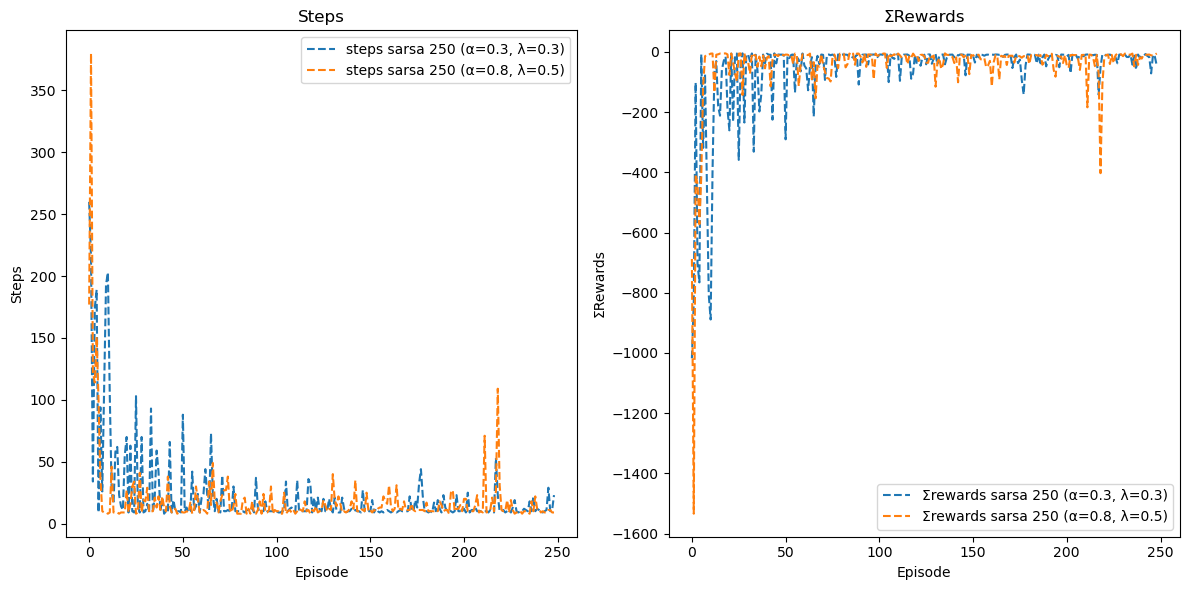

 Label                   | Total ΣRewards | Last 200 ΣRewards | Last 100 ΣRewards 
-------------------------------------------------------------------------------
sarsa_250_(α=0.3, λ=0.3) |      -14439.49 |          -4985.70 |         -2029.02
sarsa_250_(α=0.8, λ=0.5) |      -10854.23 |          -5443.29 |         -2748.65


In [7]:
with open("saved_run_data/hyperparam_tuning_250.json", "r") as f:
    hp_results_250 = json.load(f)
    
display_stored_results(hp_results_250, None)

print(" Label                   | Total ΣRewards | Last 200 ΣRewards | Last 100 ΣRewards ")
print("-------------------------------------------------------------------------------")
for model, data in hp_results_250.items():
    print(f"{model:10} | {sum(data['Rs']):14.2f} | {sum(data['Rs'][50:]):17.2f} | {sum(data['Rs'][150:]):16.2f}")

Here it is clear to see the long term benefit of low α and λ values. After 50 episodes (α=0.3, λ=0.3) clearly out-performs the other model.

<br>

### Hyper-parameter Selection

There are more hyper-parameters to consider for both Sarsaλ and our environment. In a real-world use case it would be crucial to test multiple combinations of all these parameters. However, due to the limitation of virtual machine time on this project I will discuss my choices for these parameters instead:

- The **ε** parameter for how frequently to take non-greedy actions will be set at **0.1** meaning 10% of the time a non-greedy action will be taken. This will be enough to ensure we exploit existing knowledge of the environment whilst exploring to find potentially faster paths.

- The **γ** parameter for discounting of future rewards will be set to **0.9**. This may cause the learning to converge more slowly but it will result in a more stable solution.

- For the tile-encoding parameter **num_tiles** a reasonable setting of 30 will ensure the laser scanner is data rich enough to represent our state space.

Therefore, the final parameter selection is below:

In [ ]:
env_parameters = {
    "num_lasers": 60, 
    "num_tiles": 30,
    "num_tilings": 20,
}

rl_parameters = {
    "α": 0.3/(60*20), 
    "λ": 0.3,
    "ε": 0.1,
    "γ": 0.9,
}

Now we can run a full training loop.

In [15]:
REVIEW_MODE = True

#------ Main Training Params ------#
train_from_scratch = True 
output_model_path = "" # Blank in case of accidental runs.
saved_model_path = ""
episodes = 250
max_steps = 1000

#-------- Additional Params -------#
rl_parameters["episodes"] = episodes
rl_parameters["max_t"] = max_steps
rl_parameters["seed"] = 1
rl_parameters["visual"] = False
env_parameters["single_goal"] = True

if not REVIEW_MODE:
  #-------- Initializing Environment --------#
    gz_env = start_environment(GazeboEnvV, env_parameters)

  #------------- Training -------------#
    if train_from_scratch:
        sarsa = linear.Sarsaλ(env=gz_env, **rl_parameters)
        sarsa = sarsa.interact()
        save_model(sarsa, output_model_path)
    else:
        sarsa = load_model(saved_model_path)
        sarsa.env = gz_env
        sarsa.interact(resume=True, episodes=sarsa.ep + episodes)
        save_model(sarsa, output_model_path)

    ros.shutdown()

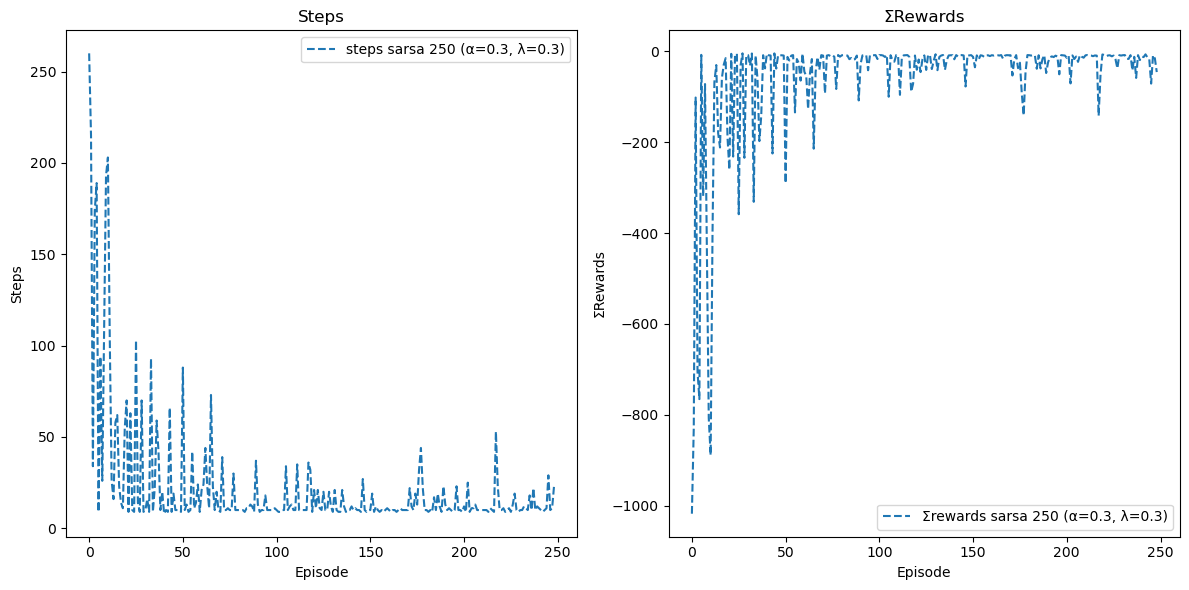

In [8]:
display_stored_results(hp_results_250, None, only_show=["sarsa_250_(α=0.3, λ=0.3)"])

As demonstrated in the graph the agent quickly achieves good results in the first 25 episodes, after which point it never takes more than 100 steps to reach the goal. From this point the number of steps trends down until after around 125 episodes where we see stable performance of under 30 steps per episode with the exception of 2 outlier episodes. 

Overall the training of the single 250 episode agent took 2h 7m on the provided Azure Virtual Machine (See section 7 for specs) 

<br>

To validate the trained model I will extend the env class to count the number of times the agent reaches the goal or hits a wall.

In [17]:
class GazeboEnvVVal(GazeboEnvV):

    def __init__(self, **kw):
        super().__init__(**kw)
        self.test_scores = {"goal": 0, "wall": 0}

    def step(self, a=1, speed=None, θspeed=None):
        sn, r, done, _ = super().step(a=a, speed=speed, θspeed=θspeed)
        
        if r == 10:
            self.test_scores["goal"] += 1
        elif r == -10:
            self.test_scores["wall"] += 1

        return sn, r, done, _

Now we can set the trained agent's policy to greedy and run. 

In [3]:
REVIEW_MODE = True

results_save_path = ""
results_load_path = "saved_run_data/validation_results_100.json"

saved_model_path = "saved_models/sarsa_250_(α=0.3, λ=0.3).pkl"
episodes = 100

env_parameters = {
    "num_lasers": 60, 
    "num_tiles": 30,
    "num_tilings": 20,
    "single_goal": True
}

if not REVIEW_MODE:
    gz_env = start_environment(GazeboEnvVVal, env_parameters)
    sarsa = load_model(saved_model_path)
    sarsa.env = gz_env

    # Fixing strange bug possibily caused by multiple resumes of the same model.
    sarsa.Rs = sarsa.Rs.copy() 
    sarsa.Es = sarsa.Es.copy()

    sarsa.policy = sarsa.greedy
    sarsa.max_t = 15
    sarsa.interact(resume=True, train=False, episodes=sarsa.ep + episodes)

    ros.shutdown()

    validation_results = gz_env.test_scores
    with open(results_save_path, "w") as f:
        f.write(json.dumps(gz_env.test_scores))
else:
    with open(results_load_path, "r") as f:
        validation_results = json.load(f)

print("Success %:", round(validation_results["goal"]/(episodes), 2)*100)
print("Fail %:", round(((episodes) - validation_results["goal"])/(episodes), 2)*100, f"(crashes: {validation_results['wall']})")

Success %: 96.0
Fail %: 4.0 (crashes: 4)


As shown above the agent reaches the goal in under 15 steps 96/100 times. 

<br>

## 4. Robot model 2: Policy Gradient with Non-linear Function Approximation

In this section we will train the agent again, but this time using a policy gradient descent method with non-linear function approximation.For this we will use a keras neural network architecture with the ActorCritic algorithmic framework.

In [19]:
from rl import deep

from tensorflow.keras.layers import Conv1D, Dense, Flatten, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

2024-05-04 14:19:35.497800: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-05-04 14:19:35.593335: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-05-04 14:19:35.595959: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-05-04 14:19:36.791511: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


For this model we can simply use the normalised scan values as the state. This will be more suitable for continuous control as the state complexity will be captured by the neural network.

Also, we must use an experience-replay mechanism to train the agent. Therefore to allow for batching I will add an additional batch dimension to the state.

Since we desire the same behaviour from the agent there is no need to change the reward function. 

In [20]:
class GazeboEnvPG(GazeboEnvV):

    def __init__(self, **kw):
        super().__init__(**kw)
    
    def step0(self):
        return self.s_(), 1
    
    def s_(self):
        state_vector = np.array(last_scans)
        state_vector = state_vector/3.5 # Normalised
        return state_vector.reshape(1, state_vector.shape[0], 1)

For the policy gradient algorithm I have chosen ActorCritic due to its ability to simultaneously learn and evaluate its policy. Therefore, we need to make suitable changes to the neural network MDP to define an Actor-Critic style update. 

The changes are as follows:

1. Switching to a 1D convolutional network.
2. Using softmax activation for the actor outputs.
3. Changing the online method to an implementation of an ActorCritic update.

In [32]:
class ActorCritic(deep.MDP):
    def __init__(self, α=1e-4, β=1e-4, t_n=50, **kw):
        print('--------------------- 🧠 Actor-Critic is being set up 🧠 -----------------------')
        super().__init__(create_vN=True, **kw)
        self.α = α
        self.β = β
        self.store = True
        self.t_n = t_n
    
    def create_model(self, net_str):
        x0 = Input(self.env.reset().shape)
        x = Conv1D(32, 8, 2, activation='relu', padding='same')(x0)
        x = Conv1D(32, 2, 2, activation='relu', padding='same')(x)
        x = Conv1D(32, 2, 1, activation='relu', padding='same')(x)
        x = Flatten()(x)
        x = Dense(self.nF, 'relu')(x)

        if net_str == 'V':
            x = Dense(1, activation='linear')(x)
            model = Model(x0, x)
            model.compile(Adam(self.α), loss='mse')
        else:
            x = Dense(self.env.nA, activation='softmax')(x)
            model = Model(x0, x)
            model.compile(Adam(self.β), loss='mse')

        model.summary() if net_str != 'Qn' else None
        model.net_str = net_str
        return model

    def online(self, *args):
        if len(self.buffer) < self.nbuffer:
            return
        
        (s, a, rn, sn, dones), inds = self.batch()

        Vs = self.V(s)
        Vn = self.V(sn)
        Vn[dones] = 0

        # Critic update
        Vn = np.squeeze(Vn, axis=-1) 
        Vs = np.squeeze(Vs, axis=-1) 
        
        td_target = rn + self.γ * Vn
        td_error = td_target - Vs

        self.V(s, Vs)

        # Actor update
        Qs = self.Q(s)
        Qs[inds, a] = Qs[inds, a] + self.α * td_error[inds]
        
        self.Q(s, Qs)
        self.Qn(sn, self.t_%self.t_n==0)

<br>

#### _Hyperparameter Tuning/Selection_

I have selected the following options for the ActorCritic hyper-parameters:

- **ε**: To allow for exploration whilst exploiting existing knowledge this will be set to 0.1.
- **α & β**: The actor and critic learning rates will both be set to 1e-4 as it is within the conventional range for neural networks. 
- **nbuffer & nbatch**: Since we require an experience-replay mechanism we can set these to 32 which will be a reasonable number of steps to 
effectively learn.

For the **(Number of Features) nF** parameter I conducted hyper-parameter tuning below:

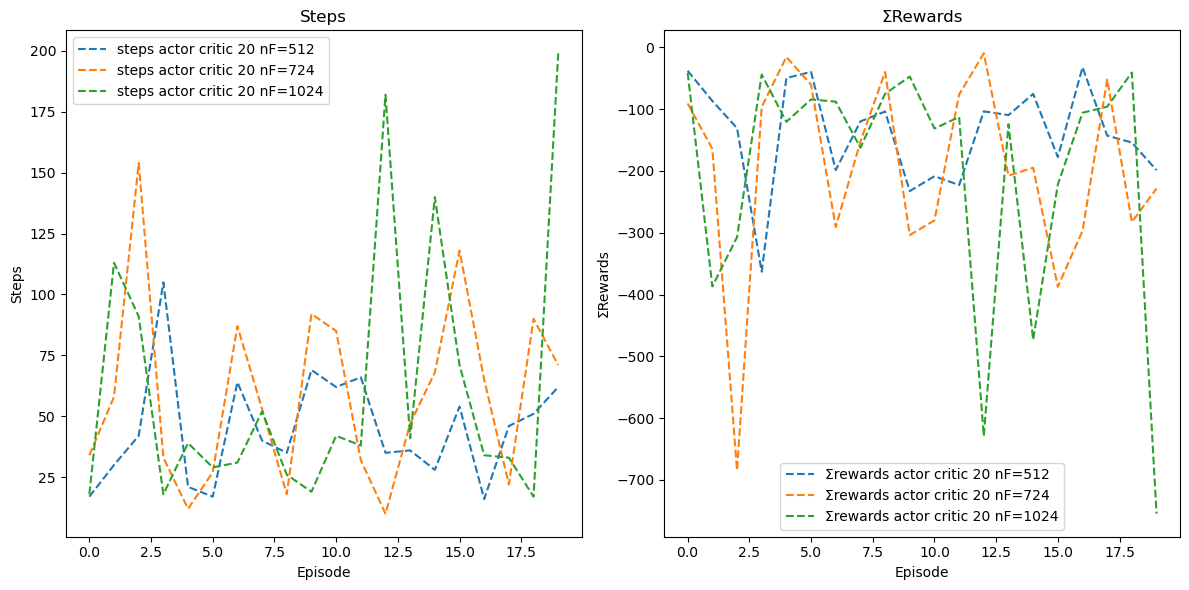

In [9]:
with open("saved_run_data/actor_critic.json", "r") as f:
    ac_results = json.load(f)
display_stored_results(ac_results)

As we can see in the graph. For all options of nF agent is frequently achieving the goal but is making little to no improvement in the rewards it receives during the episode. I will set nF to 512 as it seemed to perform with the least variance.

<br>

We can use a similar training structure as Model 1, based around the provided interact() method.

In [ ]:
REVIEW_MODE = True
train_from_scratch = True 
output_model_path = "saved_models/actor_critic_20_nF=512.pkl"
saved_model_path = ""
episodes = 20

env_parameters = {
    "single_goal": True
    }

rl_parameters = {
    "ε": 0.1,
    "α": 1e-4, 
    "β": 1e-4, 
    "nF": 512,
    "nbuffer": 32, 
    "nbatch": 32,
    "save_weights": 10000,
    "episodes": episodes,
    "max_t": 200,
    "seed": 1,
}

if not REVIEW_MODE:
  #-------- Initializing Environment --------#
    gz_env = start_environment(GazeboEnvPG, env_parameters)

  #------------- Training -------------#
    if train_from_scratch:
        actor_critic = ActorCritic(env=gz_env, **rl_parameters)
        actor_critic = actor_critic.interact()
        save_model(actor_critic, output_model_path)
    else:
        actor_critic = load_model(saved_model_path)
        actor_critic.env = actor_critic
        actor_critic.interact(resume=True, episodes=actor_critic.ep + episodes)
        save_model(actor_critic, output_model_path)

    ros.shutdown()

Below is the code with which I stored the run data.

In [12]:
if not REVIEW_MODE:
    outpath = "" # Left blank incase of accidental run.
    models = [
        "actor_critic_20_nF=512", 
        "actor_critic_20_nF=724",
        "actor_critic_20_nF=1024", 
    ]

    data = {}
    for model in models:
        sarsa_load = load_model(f"saved_models/{model}.pkl")
        data[model] = {
            "Ts": sarsa_load.Ts.tolist(),
            "Rs": sarsa_load.Rs.tolist(),
        }
        
    with open(outpath, "w") as f:
        f.write(json.dumps(data))

And now we can display the results of the best model.

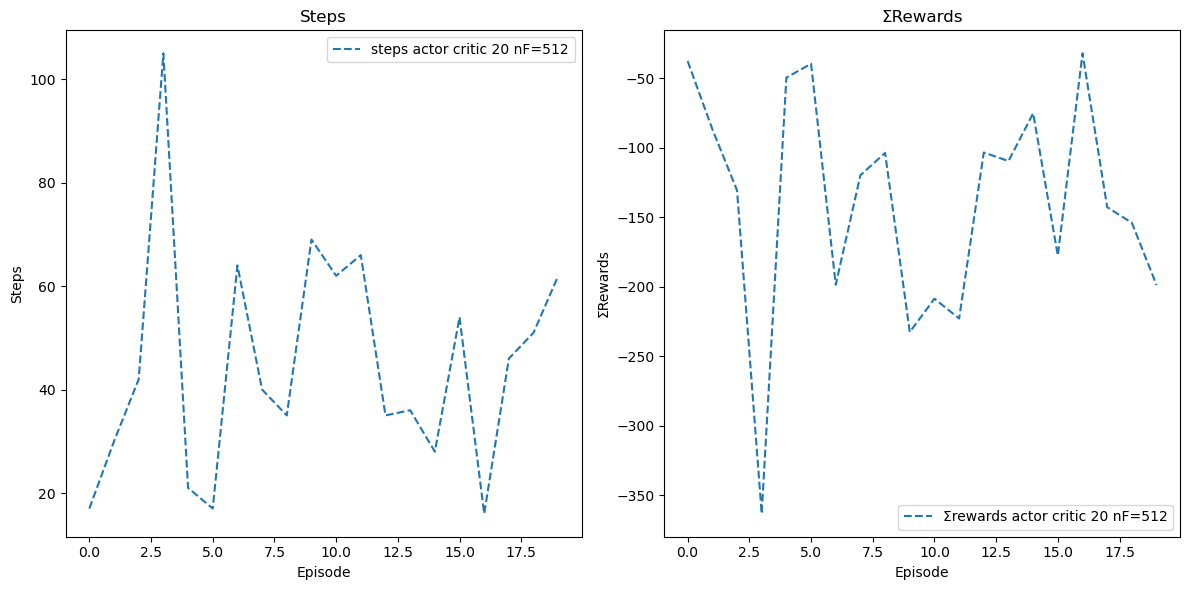

In [10]:
with open("saved_run_data/actor_critic.json", "r") as f:
    ac_results = json.load(f)
display_stored_results(ac_results, only_show=["actor_critic_20_nF=512"])

Here we can see the best performing run for this model. This run took 1hr and 43m on the Virtual Machine. After the initial 2-3 episodes there is a slight improvement in the agent's performance and throughout training it always achieves the goal within the first ~150 steps of an episode. This demonstrates some learning is occurring but disappointingly, it is clearly not converging to a stable solution. 

I believe there are some inefficiencies in the neural network architecture I have used and potentially with the experience replay mechanism and how the batches are input into thte neural network. 

Also, potentially with a longer run this may have converged but the Virual Machine would crash when run for a longer number of episodes. 

<br>

### 6. Conclusion

This project achieved success in several aspects. I successfully developed an environment class to interface with the turtlebot agent, crafted an effective state representation and reward function, and conducted hyper-parameter tuning. However, I encountered challenges in achieving convergence with the ActorCritic model.

The project faced two significant challenges. The first was limitation of the virtual machine. Not only with time restriction which limited the ability to experiment but also with the frequent crashing of the machine which hindered the ability to acheive convergence with the non-linear model. The second was the binary nature of success. In this project a small mistake in code can make the difference between a perfectly trained agent and a useless one. 

Despite these setbacks, the project was very enjoyable and an overall success. I was able to effectively demonstrate my understanding of reinforcement learning and robotics by fulfilling the brief for the first model and successfully training the agent to find the goal. I was also able to show my understanding of the brief for the second model by creating an appropriate class and implementing a policy gradient descent method with a neural network architecture.

<br>

### 7. Hardware Specs

Training was run on an Azure Labs virtual machine with the following specs:

- Processor Type: Intel(R) Xeon(R) Platinum 8272CL CPU
- Clock Speed: 2.60 GHz
- Number of Processors: 4
- Cores per Processor: 2
- Cache Size: 36,608 KB per processor
- CPU Family: 6
- Model: 85
- Stepping: 7
- CPU MHz: 2593.905 MHz
- Physical Address Sizes: 46 bits
- Virtual Address Sizes: 48 bits